Juan Manuel Tabares Uribe

Sara Mesa Gómez

# 1. Introducción

- Problema seleccionado:
Existe una alta incertidumbre en los estudiantes universitarios sobre su futuro laboral y que tan efectivos son sus esfuerzos académicos y extracurriculares para conseguir empleo al graduarse.

- Justificacion:
Cada año las empresas aumentan sus requisitos de contratación y exigen más rendimiento académico, experiencia práctica y conocimientos técnicos. Frente a la inseguridad sobre el valor de un título universitario, muchos estudiantes desisten de sus carreras para tomar caminos que consideran más seguros, o reparten su tiempo entre certificaciones, proyectos y pasantías sin saber cuáles de esos esfuerzos influyen realmente en su contratación.

Un modelo predictivo entrenado con datos de estudiantes permite ir más allá de la percepción. Por un lado, estima la probabilidad de que un estudiante sea contratado según su perfil. Por otro, mide el peso real de cada factor: el rendimiento académico, la institución, la experiencia práctica y las habilidades técnicas. Así se puede determinar si estas barreras son tan grandes como parecen o si el temor a ellas nace de la desinformación. Los resultados podrían orientar a los estudiantes sobre en qué invertir su esfuerzo y a las universidades sobre qué experiencias fortalecer en sus programas.

- Objetivo del modelo:
Predecir si un estudiante será contratado a partir de su desempeño académico, habilidades técnicas y experiencia extracurricular, e identificar qué factores pesan más en la contratación.

- Tipo de problema:
Clasificación binaria supervisada.

- Variable objetivo:
placement_status

Nota: salary_package_lpa no se usa como objetivo ni como predictor, la excluimos

###Fuente de los datos:
https://www.kaggle.com/datasets/suhanigupta04/student-placement-prediction-dataset

In [ ]:
import kagglehub
import os
import pandas as pd
path = kagglehub.dataset_download("suhanigupta04/student-placement-prediction-dataset")
print("Path to dataset files:", path)
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

Using Colab cache for faster access to the 'student-placement-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/student-placement-prediction-dataset


# 2. Descripción del conjunto de datos

- Número de observaciones:
100.000

-  Número de variables:
18

16 predictoras, 1 objetivo, 1 excluida

- Significado de la variable objetivo:

placement_status:	1 indica que el estudiante consiguió trabajo y 0 que no.

salary_package_lpa (Variable excluida): salario ofrecido; solo existe si hubo contratación.

### Tipo de variables
| Variable | Tipo de dato | Tipo variable|
|---|---|---|
|placement_status|Binario | Objetivo|
|salary_package_lpa |Continuo|Excluida|
|branch |Categorico |Predictora|
| college_tier| Categorico|Predictora|
|cgpa | Continuo|Predictora|
|backlogs | Discreto|Predictora|
|coding_skills|Continuo|Predictora|
| dsa_score|Continuo|Predictora|
|aptitude_score |Continuo|Predictora|
|communication_skills| Continuo|Predictora|
| system_design|Continuo |Predictora|
| internships|Discreto |Predictora|
| projects_count|Discreto |Predictora|
| certifications|Discreto |Predictora|
| hackathons|Discreto |Predictora|
| open_source_contributions|Discreto |Predictora|
| extracurriculars|Discreto |Predictora|
|ml_knowledge|Continuo|Predictora|

- Posibles limitaciones del conjunto de datos:
1. Datos sintéticos: Al ser un dataset generado sintéticamente las relaciones entre las variables pueden no capturar la complejidad real del mercado laboral.
2. Falta de variables cualitativas: No incluye entrevistas, factores socioeconómicos ni región.
3.  Varias variables casi no difieren entre clases.



# 3. Exploracion de Datos

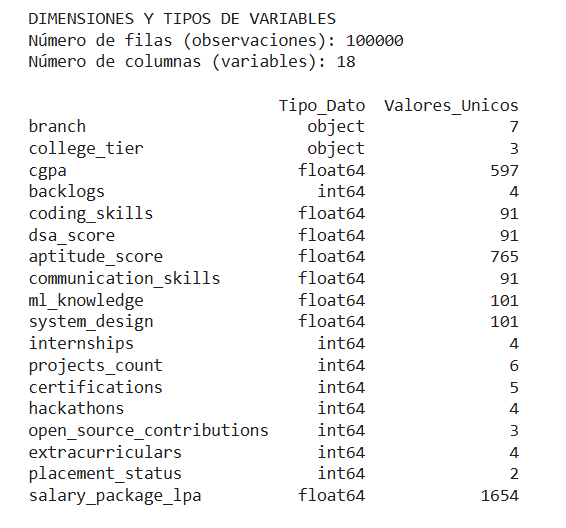

**Conclusiones – Dimensiones y tipos de variables**
- El conjunto tiene 100.000 observaciones y 18 variables, así que cumple con los mínimos de la guía (≥ 1.000 observaciones y ≥ 5 predictoras).
- `placement_status` solo toma 2 valores, lo que confirma que es un problema de **clasificación binaria**.
- `branch` (7 categorías) y `college_tier` (3 categorías) son de tipo texto y no pueden entrar directamente a un modelo. Por eso en la sección 4 se codificaron con One-Hot. Con las 14 numéricas, más 7 columnas de `branch` y 3 de `college_tier`, se obtienen las 24 columnas de `X_train`.
- Las variables de conteo (`backlogs`, `internships`, `projects_count`, `certifications`, `hackathons`, `open_source_contributions`, `extracurriculars`) tienen entre 3 y 6 valores únicos, así que son discretas. Los puntajes (`cgpa`, `coding_skills`, `aptitude_score`, etc.) son continuos.

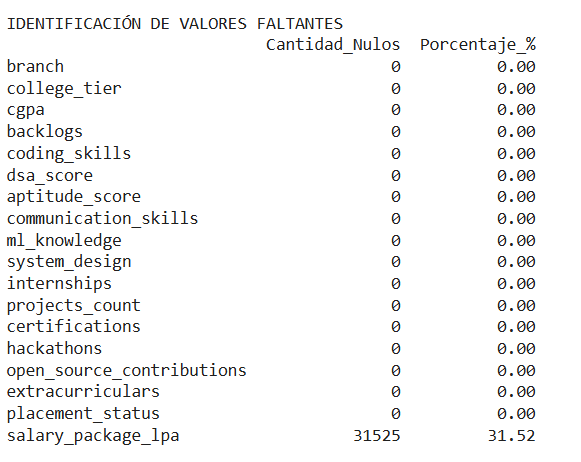

**Conclusiones – Valores faltantes**
- Ninguna de las 16 predictoras tiene valores faltantes. La única columna con nulos es `salary_package_lpa`, con 31.525 (31,52 %).
- Esos 31.525 nulos coinciden **exactamente** con el número de estudiantes no contratados (tabla de balance). No son datos perdidos: el salario no existe porque el estudiante no fue contratado. Es decir, el salario solo se conoce **después** del evento que se quiere predecir, y por eso se excluyó de las predictoras en las secciones 4 y 6. Tras excluirlo, `X` quedó con 14 variables numéricas.
- Como el dataset no trae nulos en las predictoras, y la guía exige que al menos una predictora tenga valores faltantes para que haya un proceso de tratamiento y limpieza, se simularon en la sección 4-5 (5 % aleatorio en cada predictora). Allí se cuantifican, se analiza su impacto y se justifica la estrategia de imputación.

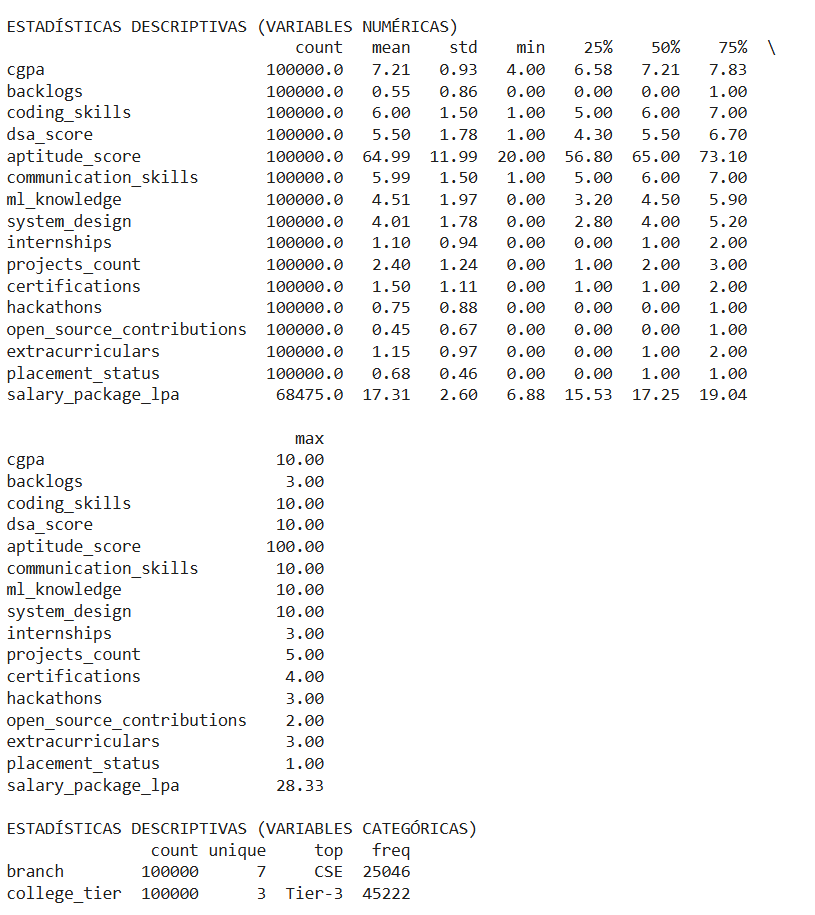

**Conclusiones – Estadísticas descriptivas**
- Todos los mínimos y máximos son plausibles: no hay negativos, `cgpa` va de 4 a 10, `aptitude_score` de 20 a 100 y los conteos de 0 a 5. No hay registros con errores que eliminar.
- Las escalas son muy distintas: `aptitude_score` tiene desviación estándar de 11,99, frente a entre 0,67 y 1,97 en las demás. Esto justifica el `StandardScaler` de la sección 4, para que esa variable no domine los coeficientes de la regresión logística.
- En las variables continuas la media y la mediana casi coinciden (`cgpa` 7,21 / 7,21; `aptitude_score` 64,99 / 65,00; `coding_skills` 6,00 / 6,00). Las distribuciones son simétricas, así que imputar con la mediana (sección 4) no desplaza la distribución.
- En las categóricas, `CSE` (25 %) y `Tier-3` (45 %) son las modas. Esos son los valores que usa el imputador por moda de la sección 4.

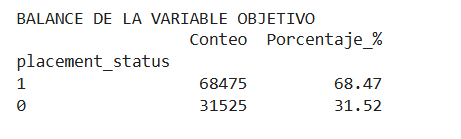

**Conclusiones – Balance de la variable objetivo**
- El 68,47 % de los estudiantes fue contratado y el 31,52 % no: hay unos 2,2 contratados por cada no contratado. El desbalance es moderado.
- **Consecuencia directa en la sección 7:** un modelo que prediga siempre "contratado" ya obtiene 68,47 % de *accuracy*. La regresión logística logra 69,69 % y el Random Forest 69,05 %, apenas entre 0,6 y 1,2 puntos por encima de esa referencia. Por eso la *accuracy* no sirve para juzgar el modelo.
- El desbalance también explica que ambos modelos detecten muy pocos no contratados: el *recall* de la clase 0 es solo de 18 % y 17 %. Los modelos tienden a predecir la clase mayoritaria. Conviene usar métricas como el F1 de la clase 0 o el ROC-AUC y probar `class_weight="balanced"`.
- La división estratificada de la sección 4 conservó la proporción. El conjunto de prueba tiene 13.695 contratados y 6.305 no contratados, es decir 68,5 % y 31,5 %, igual que el dataset completo.

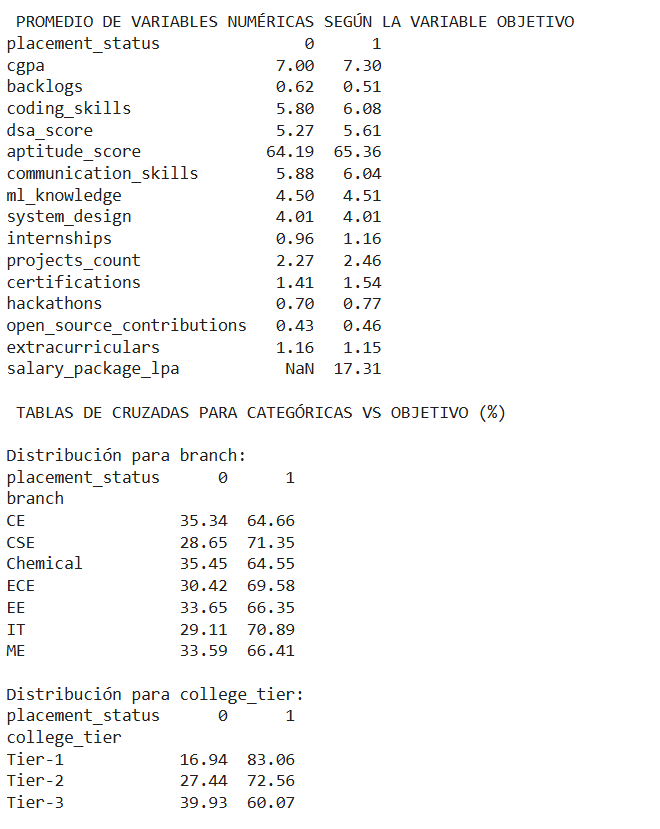

**Conclusiones – Relación de las predictoras con la variable objetivo**
- **`college_tier` es el factor más diferenciador:** la tasa de contratación baja de 83,06 % (Tier-1) a 72,56 % (Tier-2) y 60,07 % (Tier-3), una brecha de 23 puntos. La relación es ordenada: a mejor nivel de universidad, más contratación.
- **La experiencia práctica pesa más que las certificaciones:** los contratados tienen en promedio 1,16 pasantías frente a 0,96 (+21 %) y 2,46 proyectos frente a 2,27. En certificaciones la diferencia es menor (1,54 frente a 1,41).
- **El rendimiento académico influye:** los contratados tienen mayor `cgpa` (7,30 frente a 7,00) y menos materias perdidas (0,51 frente a 0,62).
- **Variables sin efecto:** `ml_knowledge` (4,50 / 4,51), `system_design` (4,01 / 4,01), `extracurriculars` (1,16 / 1,15) y `open_source_contributions` (0,43 / 0,46) prácticamente no difieren entre clases.
- **Carrera:** las de computación (CSE 71,35 %, IT 70,89 %) superan en unos 7 puntos a Civil (64,66 %) y Química (64,55 %).
- **Relación con la pregunta del proyecto y con la sección 7:** como primera respuesta, la institución, las pasantías y el promedio pesan más que las certificaciones. Sin embargo, casi todas las diferencias son pequeñas. Esto anticipa que los modelos superarían al baseline por poco, como efectivamente ocurrió (≈ 70 % de *accuracy*).

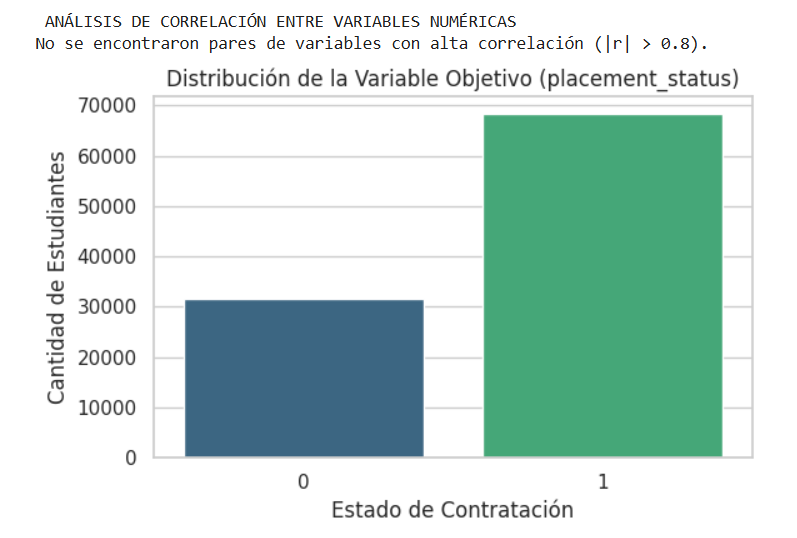

**Conclusiones – Distribución de la variable objetivo (gráfico)**
- La barra de contratados (≈ 68.000) duplica a la de no contratados (≈ 31.500), lo que confirma visualmente el desbalance.
- Aun así, la clase minoritaria tiene más de 31.000 ejemplos, suficientes para que un modelo la aprenda. El bajo *recall* de la clase 0 en la sección 7 (18 %) no se debe a falta de datos, sino a que el modelo prioriza la clase mayoritaria y a que la señal es débil. Se puede mejorar con `class_weight="balanced"` o ajustando el umbral de decisión.
- Por este desbalance fue necesario usar `stratify=y` en `train_test_split` (sección 4), para que entrenamiento y prueba conserven la misma proporción.

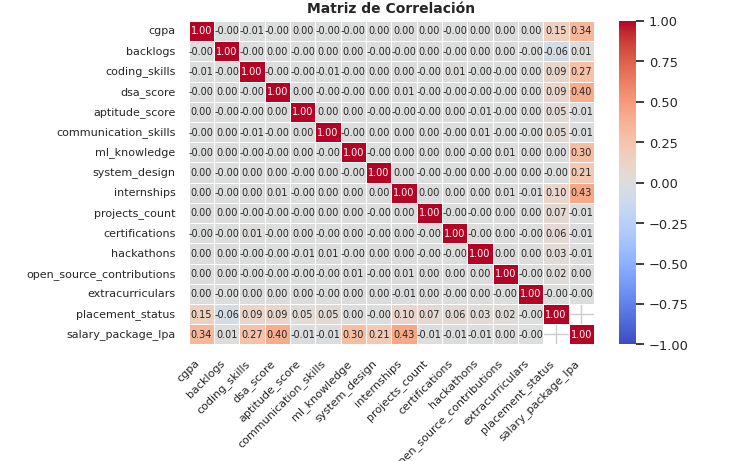

**Conclusiones – Matriz de correlación**
- **No hay redundancia:** las predictoras tienen correlaciones prácticamente nulas entre sí (|r| ≈ 0,00) y ningún par supera |r| > 0,8. Por eso en la sección 4 no se eliminó ninguna variable por correlación, y no hay multicolinealidad que afecte los coeficientes de la regresión logística.
- **La relación lineal con el objetivo es débil:** la correlación más alta con `placement_status` es la de `cgpa` (0,15), seguida de `internships` (0,10), `coding_skills` y `dsa_score` (0,09) y `projects_count` (0,07). `certifications` llega solo a 0,06, y `ml_knowledge`, `system_design` y `extracurriculars` a 0,00. Esta señal débil explica por qué ningún modelo de la sección 7 pasa de ≈ 70 % de *accuracy*.
- **Hallazgo sobre el salario:** `ml_knowledge` (0,30) y `system_design` (0,21) no influyen en *ser contratado* (0,00), pero sí se relacionan con *cuánto se paga*. Lo mismo ocurre, con más fuerza, con `internships` (0,43), `dsa_score` (0,40) y `cgpa` (0,34). Para la pregunta del proyecto: ciertas habilidades técnicas no abren la puerta, pero sí mejoran la oferta. Esto queda como trabajo futuro (un modelo de salario entrenado solo con contratados).
- La celda vacía entre `salary_package_lpa` y `placement_status` se debe a que el salario solo existe cuando `placement_status = 1`, así que no se puede calcular esa correlación. Es otra evidencia de que el salario es posterior al evento y debía excluirse.
- La independencia casi perfecta entre predictoras es poco común en datos reales y refleja que el dataset es sintético (limitación declarada en la sección 2).

#Código de analisis estadisticos

Using Colab cache for faster access to the 'student-placement-prediction-dataset' dataset.
DIMENSIONES Y TIPOS DE VARIABLES
Número de filas (observaciones): 100000
Número de columnas (variables): 18

                          Tipo_Dato  Valores_Unicos
branch                       object               7
college_tier                 object               3
cgpa                        float64             597
backlogs                      int64               4
coding_skills               float64              91
dsa_score                   float64              91
aptitude_score              float64             765
communication_skills        float64              91
ml_knowledge                float64             101
system_design               float64             101
internships                   int64               4
projects_count                int64               6
certifications                int64               5
hackathons                    int64               4
open_source_contribu

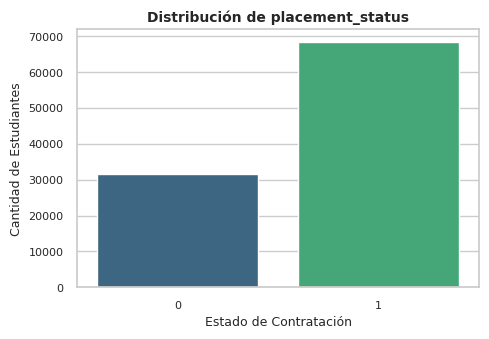

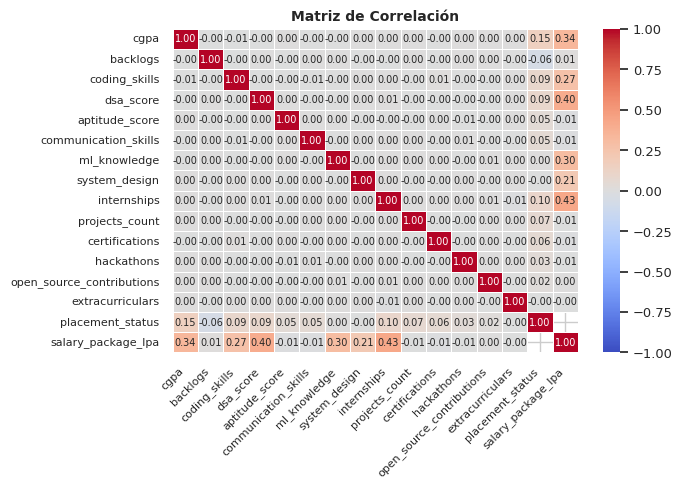

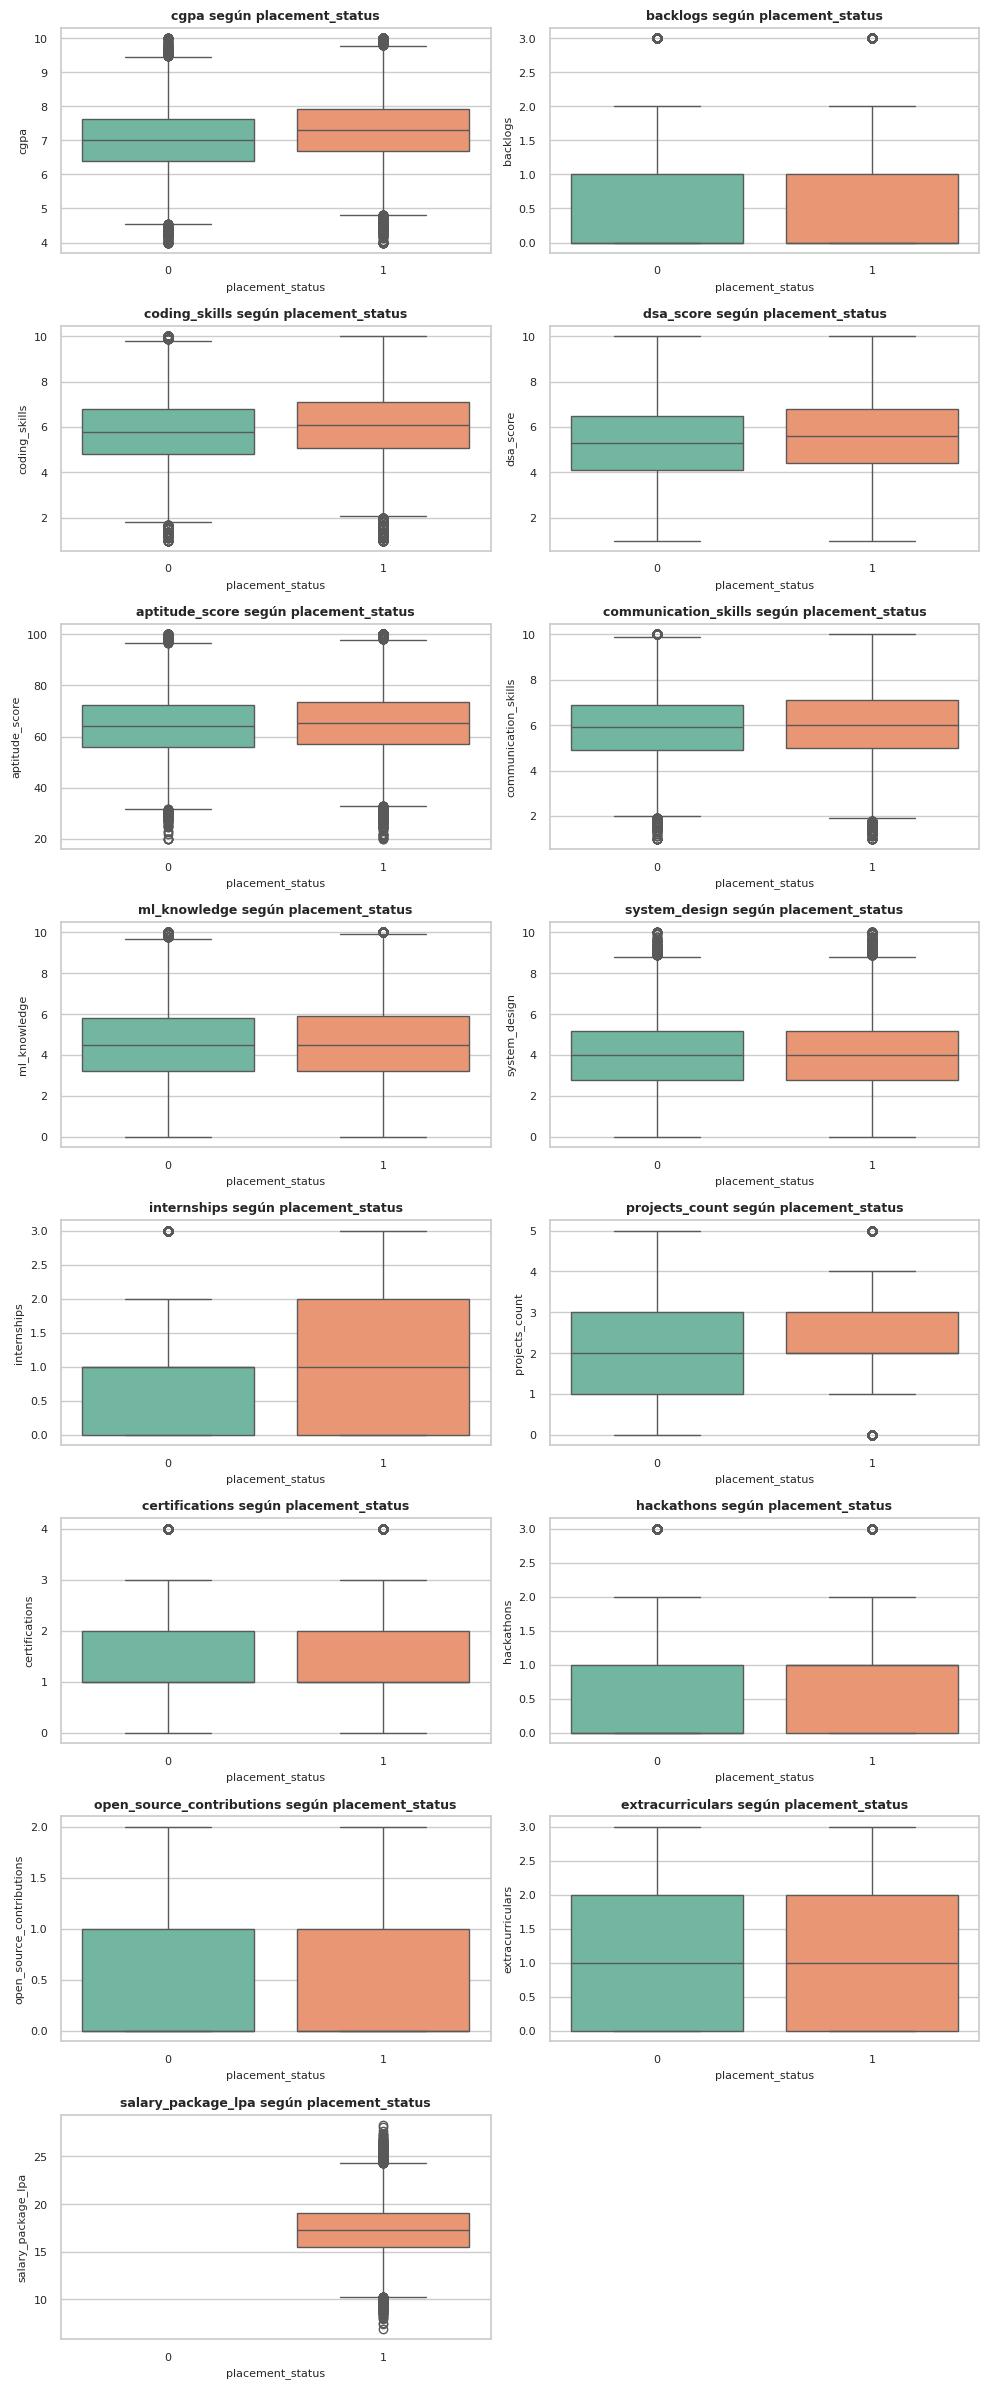

In [ ]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

path = kagglehub.dataset_download("suhanigupta04/student-placement-prediction-dataset")

archivos_csv = [f for f in os.listdir(path) if f.endswith('.csv')]
ruta_completa = os.path.join(path, archivos_csv[0])

df = pd.read_csv(ruta_completa)

TARGET = 'placement_status'

print("DIMENSIONES Y TIPOS DE VARIABLES")
print(f"Número de filas (observaciones): {df.shape[0]}")
print(f"Número de columnas (variables): {df.shape[1]}\n")

# Estructura general de las variables
info_df = pd.DataFrame({
    'Tipo_Dato': df.dtypes,
    'Valores_Unicos': df.nunique()
})
print(info_df)
print("\n" + "="*50 + "\n")

print("IDENTIFICACIÓN DE VALORES FALTANTES")
nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

df_nulos = pd.DataFrame({
    'Cantidad_Nulos': nulos,
    'Porcentaje_%': porcentaje_nulos.round(2)
})
print(df_nulos)
print("\n" + "="*50 + "\n")

print("ESTADÍSTICAS DESCRIPTIVAS (VARIABLES NUMÉRICAS)")
# Genera media, std, min, Q1 (25%), mediana (50%), Q3 (75%) y max
print(df.describe().T.round(2))

print("\nESTADÍSTICAS DESCRIPTIVAS (VARIABLES CATEGÓRICAS)")
num_categoricas = df.select_dtypes(include=['object', 'category']).columns

if len(num_categoricas) > 0:
    print(df.describe(include=['object', 'category']).T)
else:
    print("No se encontraron variables categóricas de tipo texto.")
print("\n" + "="*50 + "\n")

print("BALANCE DE LA VARIABLE OBJETIVO")
conteo_target = df[TARGET].value_counts()
porcentaje_target = df[TARGET].value_counts(normalize=True) * 100

df_target = pd.DataFrame({
    'Conteo': conteo_target,
    'Porcentaje_%': porcentaje_target.round(2)
})
print(df_target)
print("\n" + "="*50 + "\n")

print(" PROMEDIO DE VARIABLES NUMÉRICAS SEGÚN LA VARIABLE OBJETIVO ")
print(df.groupby(TARGET).mean(numeric_only=True).T.round(2))

if len(num_categoricas) > 0:
    print("\n TABLAS DE CRUZADAS PARA CATEGÓRICAS VS OBJETIVO (%)")
    for col in num_categoricas:
        print(f"\nDistribución para {col}:")
        print(pd.crosstab(df[col], df[TARGET], normalize='index').round(4) * 100)
print("\n" + "="*50 + "\n")

print(" ANÁLISIS DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS")
matriz_corr = df.corr(numeric_only=True)

correlaciones_altas = []
for i in range(len(matriz_corr.columns)):
    for j in range(i):
        val = matriz_corr.iloc[i, j]
        if abs(val) > 0.8:
            correlaciones_altas.append((matriz_corr.columns[i], matriz_corr.columns[j], round(val, 3)))

if correlaciones_altas:
    print("Se hallaron las siguientes variables con alta correlación (|r| > 0.8):")
    for var1, var2, corr in correlaciones_altas:
        print(f"- {var1} y {var2}: Coeficiente = {corr}")
else:
    print("No se encontraron pares de variables con alta correlación (|r| > 0.8).")

# 7. GENERACIÓN DE GRÁFICOS (EDA VISUAL - TAMAÑOS AJUSTADOS)

# Ajustar escala global de texto (0.8 reduce el tamaño predeterminado)
sns.set_theme(style="whitegrid", font_scale=0.85)

# Gráfico 1: Balance de la Variable Objetivo
plt.figure(figsize=(5, 3.5))
sns.countplot(data=df, x=TARGET, hue=TARGET, palette='viridis', legend=False)
plt.title(f'Distribución de {TARGET}', fontsize=10, fontweight='bold')
plt.xlabel('Estado de Contratación', fontsize=9)
plt.ylabel('Cantidad de Estudiantes', fontsize=9)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Gráfico 2: Mapa de Calor de Correlación
plt.figure(figsize=(7, 5))
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 7}  # Tamaño de los números dentro del mapa de calor
)
plt.title('Matriz de Correlación', fontsize=10, fontweight='bold')
plt.xticks(fontsize=8, rotation=45, ha='right')  # Rotación para que no se traslapen los nombres
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Gráfico 3: Boxplots para detectar Outliers
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
if TARGET in cols_numericas:
    cols_numericas.remove(TARGET)

# Calculamos filas necesarias ampliando el espacio vertical
n_cols = 2
n_filas = int(np.ceil(len(cols_numericas) / n_cols))

plt.figure(figsize=(10, n_filas * 3)) # Altura dinámica según el número de variables

for i, col in enumerate(cols_numericas, 1):
    plt.subplot(n_filas, n_cols, i)
    sns.boxplot(data=df, x=TARGET, y=col, hue=TARGET, palette='Set2', legend=False)
    plt.title(f'{col} según {TARGET}', fontsize=9, fontweight='bold')
    plt.xlabel(TARGET, fontsize=8)
    plt.ylabel(col, fontsize=8)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)

# wspace y hspace añaden separación entre subgráficos para evitar colisiones
plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.tight_layout()
plt.show()




**Conclusiones – Diagramas de caja por clase**
- **Las cajas de ambas clases se solapan casi por completo** en todas las variables. Ninguna variable separa por sí sola a contratados de no contratados, así que el modelo tiene que combinar varias. Esto explica el desempeño moderado de la sección 7 y la dificultad para identificar a los no contratados (*recall* de la clase 0 ≈ 18 %).
- **Las diferencias visibles están en la experiencia práctica y el rendimiento:** en `internships` la mediana pasa de 0 a 1 y el tercer cuartil de 1 a 2; en `projects_count` el primer cuartil sube de 1 a 2. Las cajas de `cgpa`, `coding_skills` y `dsa_score` están algo más arriba en los contratados.
- **Las cajas son idénticas** en `ml_knowledge`, `system_design`, `certifications`, `hackathons`, `open_source_contributions` y `extracurriculars`. Coincide con las medias y la correlación, y apunta a que las certificaciones tienen menos peso que las pasantías.
- **Valores atípicos:** los puntos fuera de los bigotes (`cgpa` < 4,5; `aptitude_score` < 32; `backlogs` = 3; `certifications` = 4) están dentro del rango válido de cada variable. Son estudiantes reales y poco comunes, no errores, así que **no se eliminaron**. Su presencia respalda usar la mediana, que es robusta, en la imputación de la sección 4.
- **Evidencia visual de fuga:** el diagrama de `salary_package_lpa` solo tiene caja para la clase 1, porque no existe salario sin contratación. Si se usara como predictor, el modelo aprendería la regla "tiene salario → contratado". Por eso se excluyó en las secciones 4 y 6.

### Conclusión general de la exploración
1. El problema es de clasificación binaria con un desbalance moderado (68/32). Por eso se usó división estratificada, y la *accuracy* no basta para evaluar el modelo.
2. `salary_package_lpa` es una variable posterior al evento (sus nulos coinciden con los no contratados y su caja solo existe para la clase 1), así que se excluyó para evitar fuga de información.
3. Las predictoras no tienen nulos ni redundancia, sus rangos son válidos y sus escalas distintas. Esto justifica simular nulos, imputar con la mediana y la moda, estandarizar y conservar todas las variables y los atípicos.
4. Los factores con más relación con la contratación son `college_tier`, las pasantías, el `cgpa`, las materias perdidas y los proyectos. Las certificaciones aportan poco, y `ml_knowledge`, `system_design`, `extracurriculars` y `open_source_contributions` casi nada.
5. La señal de cada variable es débil (correlación máxima 0,15 con el objetivo). Por eso es razonable que los modelos de la sección 7 queden cerca de 70 % de *accuracy*, solo un poco por encima del 68,47 % que se obtiene prediciendo siempre la clase mayoritaria.

# 4-5. Preparación y separación de los datos
- Transformaciones y decisiones

Prevención de Fuga de Información (Data Leakage):
Se realizó la partición del conjunto de datos en 80% entrenamiento y 20% prueba antes de aplicar cualquier transformación.
Las métricas estadísticas (como la mediana para imputar o los parámetros $\mu$ y $\sigma$ para escalar) se calcularon sobre X_train y se aplicaron a X_test.

- Separación de entrenamiento y prueba

Porcentajes: 80% para entrenamiento (80.000 filas) y 20% para prueba (20.000 filas).

Método: se utilizó train_test_split de forma aleatoria y estratificada por placement_status (stratify=y), con random_state=42. La estratificación mantiene la misma proporción de contratados y no contratados (≈ 68% / 32%) en ambos conjuntos, y la semilla hace que la división sea reproducible.

Grupos naturales: cada fila corresponde a un estudiante distinto; no hay identificadores ni varios registros de la misma persona. Por eso, una separación aleatoria no reparte información de un mismo estudiante entre entrenamiento y prueba.

- Exclusión de la variable salary_package_lpa: Se excluyó la variable salary_package_lpa porque solo existe cuando el estudiante fue contratado. Sus 31.525 valores nulos coinciden exactamente con los 31.525 estudiantes no contratados, es decir, es una variable que se conoce después del evento que se quiere predecir y no estaría disponible al momento de hacer una predicción (ver sección 6).

- Selección de variables: Se conservaron las 16 predictoras restantes. Ningún par de variables numéricas supera |r| > 0,8 (sección 3), por lo que no hay redundancia que justifique eliminar alguna, y todas están disponibles antes de la decisión de contratación.

- Valores Faltantes

Origen y cuantificación: El conjunto de datos original no tiene valores faltantes en las predictoras, por lo que se simularon de forma aleatoria (completamente al azar) y reproducible (semilla 42): un 5% en cada una de las 16 predictoras. En la celda siguiente se cuantifican los nulos por variable.

Impacto: Como los nulos están repartidos al azar entre 16 columnas, cerca del 56% de las filas tiene al menos un valor faltante, y eliminarlas dejaría solo alrededor de 44.000 de las 100.000 observaciones (ver la salida de la celda siguiente).

Variables Numéricas: Se seleccionó la imputación por la mediana en lugar de la media debido a que valores atípicos no afectan la mediana. Además, en estas variables la media y la mediana casi coinciden (por ejemplo, cgpa 7,21 / 7,21 y aptitude_score 64,99 / 65,00), así que la imputación no desplaza la distribución.

Variables Categóricas: Se utilizó la imputación por la moda, con la estructura categórica original sin perder registros.

No eliminación de registros: No se eliminaron las filas con datos faltantes porque esto habría reducido el tamaño de la muestra a menos de la mitad y recortado la capacidad de generalización del modelo. Además, como los nulos son aleatorios, eliminarlos no aporta ninguna ventaja.

- Codificación de Variables Categóricas:
Se aplicó One-Hot Encoding para las características cualitativas nominales. Esto permite que los modelos basados en álgebra lineal e interpretación geométrica procesen las categorías como vectores binarios independientes sin asumir un falso orden numérico implícito. En branch las categorías no tienen orden. En college_tier sí existe un orden (Tier-1 > Tier-2 > Tier-3), pero con One-Hot no se supone que la distancia entre Tier-1 y Tier-2 sea igual a la de Tier-2 a Tier-3.

- Escalamiento de Características:
Se aplicó StandardScaler para estandarizar las variables numéricas a media 0 y varianza 1. Esto previene que variables con rangos numéricos elevados (como aptitude_score, que va de 20 a 100) dominen sobre variables de escalas pequeñas (como promedios, puntajes de 0 a 10 o conteos) durante el cálculo de coeficientes y distancias del modelo.

- Valores atípicos:
No se eliminaron. Los valores extremos observados en los diagramas de caja (por ejemplo, cgpa < 4,5 o backlogs = 3) están dentro del rango válido de cada variable y corresponden a estudiantes reales poco comunes, no a errores de registro.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Se excluye la variable del salario
X = df.drop(columns=['placement_status', 'salary_package_lpa']).copy()
#Separar la variable objetivo
y = df['placement_status']
print(f"Predictoras: {X.shape[1]} | Observaciones: {X.shape[0]}\n")

# Simulación de valores faltantes (5 % aleatorio en cada predictora, semilla 42)
np.random.seed(42)
mascara = np.random.rand(*X.shape) < 0.05
X = X.mask(mascara)

# Cuantificación de los nulos por variable
tabla_nulos = pd.DataFrame({
    'Cantidad_Nulos': X.isnull().sum(),
    'Porcentaje_%': (X.isnull().mean() * 100).round(2)
})
print("VALORES FALTANTES POR VARIABLE")
print(tabla_nulos)

# Impacto de eliminar las filas con nulos
filas_con_nulo = X.isnull().any(axis=1).mean() * 100
print(f"\nFilas con al menos un nulo: {filas_con_nulo:.2f} %")
print(f"Filas que quedarían si se eliminaran las incompletas: {X.dropna().shape[0]} de {X.shape[0]}")

# Efecto sobre la distribución: media y mediana originales frente a la media con nulos
cols_num = X.select_dtypes('number').columns
comparacion = pd.DataFrame({
    'Media_original': df[cols_num].mean(),
    'Mediana_original': df[cols_num].median(),
    'Media_con_nulos': X[cols_num].mean()
}).round(2)
print("\nCOMPARACIÓN DE LA DISTRIBUCIÓN")
print(comparacion)

print("\nModa de las categóricas:", {c: X[c].mode()[0] for c in X.select_dtypes('object').columns})

Predictoras: 16 | Observaciones: 100000

VALORES FALTANTES POR VARIABLE
                           Cantidad_Nulos  Porcentaje_%
branch                               4885          4.88
college_tier                         5034          5.03
cgpa                                 4942          4.94
backlogs                             4966          4.97
coding_skills                        4823          4.82
dsa_score                            4796          4.80
aptitude_score                       4909          4.91
communication_skills                 4951          4.95
ml_knowledge                         5006          5.01
system_design                        4920          4.92
internships                          5054          5.05
projects_count                       5131          5.13
certifications                       5033          5.03
hackathons                           5036          5.04
open_source_contributions            5053          5.05
extracurriculars                

In [ ]:
#Separación de datos: 80% Entrenamiento y 20% Prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Entrenamiento: {X_train.shape[0]} filas ({X_train.shape[0]/len(X):.0%})")
print(f"Prueba: {X_test.shape[0]} filas ({X_test.shape[0]/len(X):.0%})\n")
print("Proporción de la variable objetivo en cada conjunto (%):")
print(pd.DataFrame({
    'Train_%': (y_train.value_counts(normalize=True) * 100).round(2),
    'Test_%': (y_test.value_counts(normalize=True) * 100).round(2)
}))

# Transformaciones
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nVariables Numéricas ({len(num_cols)}): {num_cols}")
print(f"Variables Categóricas ({len(cat_cols)}): {cat_cols}")

# Numéricas: imputación por mediana + estandarización
pipeline_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categóricas: imputación por moda + One-Hot
pipeline_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocesador = ColumnTransformer(transformers=[
    ('num', pipeline_numerico, num_cols),
    ('cat', pipeline_categorico, cat_cols)
])

# fit con entrenamiento y transform en prueba con los parámetros aprendidos en entrenamiento
X_train_preprocesado = preprocesador.fit_transform(X_train)
X_test_preprocesado = preprocesador.transform(X_test)

nombres_cat = preprocesador.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols)
columnas_totales = num_cols + list(nombres_cat)
X_train_ready = pd.DataFrame(X_train_preprocesado, columns=columnas_totales)
X_test_ready = pd.DataFrame(X_test_preprocesado, columns=columnas_totales)

print("\nTRANSFORMACIÓN")
print(f"X_train: {X_train_ready.shape} | X_test: {X_test_ready.shape}")
print("Nulos restantes después de imputar:", int(X_train_ready.isnull().sum().sum()))

Entrenamiento: 80000 filas (80%)
Prueba: 20000 filas (20%)

Proporción de la variable objetivo en cada conjunto (%):
                  Train_%  Test_%
placement_status                 
1                   68.47   68.47
0                   31.52   31.52

Variables Numéricas (14): ['cgpa', 'backlogs', 'coding_skills', 'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge', 'system_design', 'internships', 'projects_count', 'certifications', 'hackathons', 'open_source_contributions', 'extracurriculars']
Variables Categóricas (2): ['branch', 'college_tier']

TRANSFORMACIÓN
X_train: (80000, 24) | X_test: (20000, 24)
Nulos restantes después de imputar: 0


# 6. Prevención de fuga de información

Para garantizar la validez del modelo se implementaron las siguientes medidas de control:
- Exclusión estricta de la variable objetivo: La variable TARGET (placement_status) fue aislada antes de construir la matriz de características X, impidiendo que el modelo acceda directamente o deduzca el resultado final durante el aprendizaje.
- Partición previa Train/Test: Se realizó la división del dataset (80% entrenamiento y 20% prueba) de manera inicial con train_test_split, antes de cualquier imputación, escalamiento o codificación. Se verifica que ningún registro aparezca a la vez en entrenamiento y prueba.
- Ajuste exclusivo de transformadores en Entrenamiento: Los parámetros de imputación (mediana/moda), escalamiento (StandardScaler) y codificación (OneHotEncoder) se calcularon mediante el método .fit() únicamente con datos de X_train. Estos parámetros se aplicaron con .transform() a X_test. Se verifica que la mediana del imputador y la media del escalador coinciden con las calculadas en X_train.
- Análisis temporal y pertinencia de variables: Se verificó que ninguna variable predictora dependa de eventos ocurridos con posterioridad a la decisión de contratación. La variable salary_package_lpa es nula exactamente para los estudiantes no contratados, es decir, solo se conoce después de la contratación. Si se usara como predictora, el modelo aprendería la regla "tiene salario → contratado" y daría métricas falsamente altas que no se mantendrían con datos nuevos. Por eso se excluyó de X. El dataset no tiene variables de fecha, así que no hay riesgo de usar información del futuro para predecir el pasado.
- Registros repetidos: Se revisa que no existan filas idénticas en entrenamiento y prueba. Si las hubiera, el modelo las reconocería en prueba en lugar de predecirlas, lo que inflaría las métricas.
- Grupos naturales: Cada fila corresponde a un estudiante distinto y no hay identificadores ni registros repetidos de la misma persona, por lo que no existe fuga de información por grupos.

In [ ]:
TARGET = 'placement_status'

# Variable posterior al evento: el salario solo existe si hubo contratación
salario_nulo = df['salary_package_lpa'].isnull()
no_contratado = df[TARGET] == 0
print(f"Nulos en salario: {salario_nulo.sum()} | No contratados: {no_contratado.sum()}")
print("¿Salario nulo ⇔ no contratado?:", (salario_nulo == no_contratado).all())
assert 'salary_package_lpa' not in X_train.columns, "El salario está en las predictoras"

#Confirmar que el objetivo no está entre las predictoras
assert TARGET not in X_train.columns, "La variable objetivo está en las predictoras"

# Revisa que ningún registro está en entrenamiento y prueba a la vez
assert len(set(X_train.index) & set(X_test.index)) == 0, "Hay registros compartidos entre train y test"

#Imputador y escalador ajustados solo con entrenamiento
imputador_num = preprocesador.named_transformers_['num']['imputer']
scaler = preprocesador.named_transformers_['num']['scaler']
assert np.allclose(imputador_num.statistics_, X_train[num_cols].median().values), \
    "La mediana no se calculó solo con entrenamiento"
medias_train = X_train[num_cols].fillna(X_train[num_cols].median()).mean().values
assert np.allclose(scaler.mean_, medias_train), "El escalador no se ajustó solo con entrenamiento"
print("Imputador y escalador ajustados únicamente con X_train.")

#Filas idénticas entre entrenamiento y prueba
repetidos = pd.merge(X_train.drop_duplicates(), X_test.drop_duplicates(), how='inner').shape[0]
print(f"Filas idénticas en entrenamiento y prueba: {repetidos}")

print("\nTodas las verificaciones de fuga de información se superaron.")

Nulos en salario: 31525 | No contratados: 31525
¿Salario nulo ⇔ no contratado?: True
Imputador y escalador ajustados únicamente con X_train.
Filas idénticas en entrenamiento y prueba: 0

Todas las verificaciones de fuga de información se superaron.
